Problem Statement

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

Acknowledgments

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset.

Import standard libraries

In [1]:
#import libraries
import sys
print('Python: {}'.format(sys.version))
import scipy
print('scipy: {}'.format(scipy.__version__))
import numpy as np
print('numpy: {}'.format(np.__version__))
import matplotlib
import matplotlib.pyplot as plt
print('matplotlib: {}'.format(matplotlib.__version__))
import pandas as pd
print('pandas: {}'.format(pd.__version__))
import sklearn 
print('sklearn: {}'.format(sklearn.__version__))
import seaborn as sns
print('seaborn: {}'.format(sns.__version__))

Python: 3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) 
[GCC 7.3.0]
scipy: 1.4.1
numpy: 1.18.5
matplotlib: 3.2.1
pandas: 1.0.3
sklearn: 0.23.1
seaborn: 0.10.0


Read files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [3]:
#Load datasets
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
submission = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")

In [4]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
submission

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
...,...,...
1454,2915,167081.220949
1455,2916,164788.778231
1456,2917,219222.423400
1457,2918,184924.279659


In [6]:
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


Drop Id

In [7]:
train.drop('Id', axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

Describe target variable

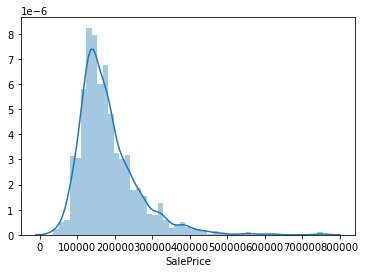

In [8]:
sns.distplot(train['SalePrice']);

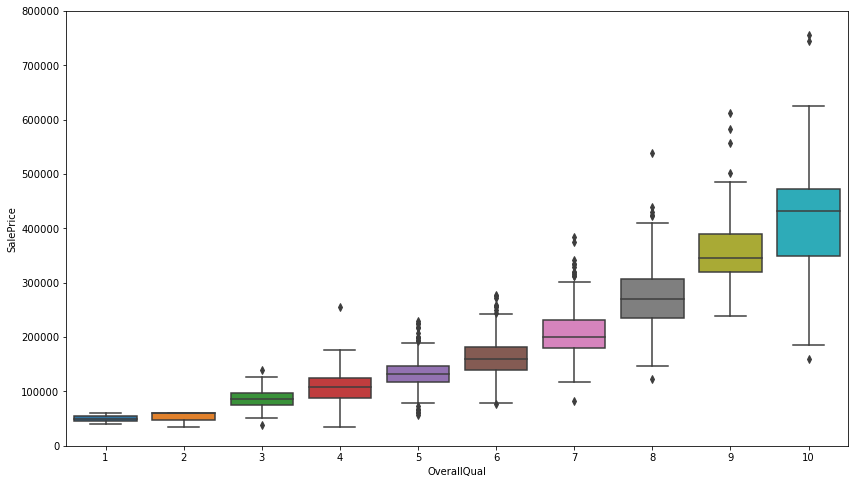

In [9]:
var = 'OverallQual'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

Check for null values

In [10]:
total = train.isnull().sum().sort_values(ascending=False)
percent = (train.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageType,81,0.055479
GarageCond,81,0.055479
GarageFinish,81,0.055479
GarageQual,81,0.055479


In [11]:
total = test.isnull().sum().sort_values(ascending=False)
percent = (test.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1456.0,0.997260
MiscFeature,1408.0,0.964384
Alley,1352.0,0.926027
Fence,1169.0,0.800685
FireplaceQu,730.0,0.500000
LotFrontage,227.0,0.155479
GarageCond,78.0,0.053425
GarageFinish,78.0,0.053425
GarageYrBlt,78.0,0.053425
GarageQual,78.0,0.053425


Impute null values

In [12]:
# fill up missing values with the not listed or median
train['MSZoning'] = train['MSZoning'].fillna('Not Listed')
train['Alley'] = train['Alley'].fillna('Not Listed')
train['Utilities'] = train['Utilities'].fillna('Not Listed')
train['Exterior1st'] = train['Exterior1st'].fillna('Not Listed')
train['Exterior2nd'] = train['Exterior2nd'].fillna('Not Listed')
train["MasVnrType"] = train["MasVnrType"].fillna('Not Listed')
train["MasVnrArea"] = train["MasVnrArea"].fillna(train['MasVnrArea'].median())
train['Electrical'] = train['Electrical'].fillna('Not Listed')
train['KitchenQual'] = train['KitchenQual'].fillna('Not Listed')
train['FireplaceQu'] = train['FireplaceQu'].fillna('Not Listed')
train['PoolQC'] = train['PoolQC'].fillna('Not Listed')
train['MiscFeature'] = train['MiscFeature'].fillna('Not Listed')
train['Fence'] = train['Fence'].fillna('Not Listed')
train['Functional'] = train['Functional'].fillna('Not Listed')
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
train['SaleType'] = train['SaleType'].fillna('Not Listed')
train['GarageType'] = train['GarageType'].fillna('Not Listed')
train['GarageFinish'] = train['GarageFinish'].fillna('Not Listed')
train['GarageQual'] = train['GarageQual'].fillna('Not Listed')
train['GarageCond'] = train['GarageCond'].fillna('Not Listed')
train['BsmtFinSF1'] = train['BsmtFinSF1'].fillna(train['BsmtFinSF1'].median())
train['BsmtFinSF2'] = train['BsmtFinSF2'].fillna(train['BsmtFinSF2'].median())

# fill up missing values with not listed or median
test['MSZoning'] = test['MSZoning'].fillna('Not Listed')
test['Alley'] = test['Alley'].fillna('Not Listed')
test['Utilities'] = test['Utilities'].fillna('Not Listed')
test['Exterior1st'] = test['Exterior1st'].fillna('Not Listed')
test['Exterior2nd'] = test['Exterior2nd'].fillna('Not Listed')
test["MasVnrType"] = test["MasVnrType"].fillna('Not Listed')
test["MasVnrArea"] = test["MasVnrArea"].fillna(test['MasVnrArea'].median())
test['Electrical'] = test['Electrical'].fillna('Not Listed')
test['KitchenQual'] = test['KitchenQual'].fillna('Not Listed')
test['FireplaceQu'] = test['FireplaceQu'].fillna('Not Listed')
test['PoolQC'] = test['PoolQC'].fillna('Not Listed')
test['MiscFeature'] = test['MiscFeature'].fillna('Not Listed')
test['Fence'] = test['Fence'].fillna('Not Listed')
test['Functional'] = test['Functional'].fillna('Not Listed')
test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].median())
test['SaleType'] = test['SaleType'].fillna('Not Listed')
test['GarageType'] = test['GarageType'].fillna('Not Listed')
test['GarageFinish'] = test['GarageFinish'].fillna('Not Listed')
test['GarageQual'] = test['GarageQual'].fillna('Not Listed')
test['GarageCond'] = test['GarageCond'].fillna('Not Listed')
test['BsmtFinSF1'] = test['BsmtFinSF1'].fillna(test['BsmtFinSF1'].median())
test['BsmtFinSF2'] = test['BsmtFinSF2'].fillna(test['BsmtFinSF2'].median())

   
# for these columns, NA = No Basement
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
   train[col] = train[col].fillna('None')
   test[col] = test[col].fillna('None')

   # for these columns, NA is likely to be 0 due to no basement
for col in ('BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
   train[col] = train[col].fillna(0)
   test[col] = test[col].fillna(0)

# as there is no garage, NA value for this column is set to zero
for col in ('GarageArea', 'GarageCars', 'GarageYrBlt'):
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

In [13]:
# checking for any null value left
train.isnull().sum().sum(), test.isnull().sum().sum()

(0, 0)

Ordinal encode

In [14]:
#ordinal encoder
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()

train.MSZoning = enc.fit_transform(train.MSZoning.values.reshape(-1,1))
train.Street = enc.fit_transform(train.Street.values.reshape(-1,1))
train.Alley = enc.fit_transform(train.Alley.values.reshape(-1,1))
train.LotShape = enc.fit_transform(train.LotShape.values.reshape(-1,1))
train.LandContour = enc.fit_transform(train.LandContour.values.reshape(-1,1))
train.Utilities = enc.fit_transform(train.Utilities.values.reshape(-1,1))
train.LotConfig = enc.fit_transform(train.LotConfig.values.reshape(-1,1))
train.LandSlope = enc.fit_transform(train.LandSlope.values.reshape(-1,1))
train.Neighborhood = enc.fit_transform(train.Neighborhood.values.reshape(-1,1))
train.Condition1 = enc.fit_transform(train.Condition1.values.reshape(-1,1))
train.Condition2 = enc.fit_transform(train.Condition2.values.reshape(-1,1))
train.BldgType = enc.fit_transform(train.BldgType.values.reshape(-1,1))
train.HouseStyle = enc.fit_transform(train.HouseStyle.values.reshape(-1,1))
train.RoofStyle = enc.fit_transform(train.RoofStyle.values.reshape(-1,1))
train.RoofMatl = enc.fit_transform(train.RoofMatl.values.reshape(-1,1))
train.Exterior1st = enc.fit_transform(train.Exterior1st.values.reshape(-1,1))
train.Exterior2nd = enc.fit_transform(train.Exterior2nd.values.reshape(-1,1))
train.MasVnrType = enc.fit_transform(train.MasVnrType.values.reshape(-1,1))
train.ExterQual = enc.fit_transform(train.ExterQual.values.reshape(-1,1))
train.ExterCond = enc.fit_transform(train.ExterCond.values.reshape(-1,1))
train.Foundation = enc.fit_transform(train.Foundation.values.reshape(-1,1))
train.BsmtQual = enc.fit_transform(train.BsmtQual.values.reshape(-1,1))
train.BsmtCond = enc.fit_transform(train.BsmtCond.values.reshape(-1,1))
train.BsmtExposure = enc.fit_transform(train.BsmtExposure.values.reshape(-1,1))
train.BsmtFinType1 = enc.fit_transform(train.BsmtFinType1.values.reshape(-1,1))
train.BsmtFinSF1 = enc.fit_transform(train.BsmtFinSF1.values.reshape(-1,1))
train.BsmtFinType2 = enc.fit_transform(train.BsmtFinType2.values.reshape(-1,1))
train.BsmtFinSF2 = enc.fit_transform(train.BsmtFinSF2.values.reshape(-1,1))
train.Heating = enc.fit_transform(train.Heating.values.reshape(-1,1))
train.HeatingQC = enc.fit_transform(train.HeatingQC.values.reshape(-1,1))
train.CentralAir = enc.fit_transform(train.CentralAir.values.reshape(-1,1))
train.Electrical = enc.fit_transform(train.Electrical.values.reshape(-1,1))
train.KitchenQual = enc.fit_transform(train.KitchenQual.values.reshape(-1,1))
train.Functional = enc.fit_transform(train.Functional.values.reshape(-1,1))
train.FireplaceQu = enc.fit_transform(train.FireplaceQu.values.reshape(-1,1))
train.GarageType = enc.fit_transform(train.GarageType.values.reshape(-1,1))
train.GarageFinish = enc.fit_transform(train.GarageFinish.values.reshape(-1,1))
train.GarageQual = enc.fit_transform(train.GarageQual.values.reshape(-1,1))
train.GarageCond = enc.fit_transform(train.GarageCond.values.reshape(-1,1))
train.PavedDrive = enc.fit_transform(train.PavedDrive.values.reshape(-1,1))
train.PoolQC = enc.fit_transform(train.PoolQC.values.reshape(-1,1))
train.Fence = enc.fit_transform(train.Fence.values.reshape(-1,1))
train.MiscFeature = enc.fit_transform(train.MiscFeature.values.reshape(-1,1))
train.SaleType = enc.fit_transform(train.SaleType.values.reshape(-1,1))
train.SaleCondition = enc.fit_transform(train.SaleCondition.values.reshape(-1,1))


test.MSZoning = enc.fit_transform(test.MSZoning.values.reshape(-1,1))
test.Street = enc.fit_transform(test.Street.values.reshape(-1,1))
test.Alley = enc.fit_transform(test.Alley.values.reshape(-1,1))
test.LotShape = enc.fit_transform(test.LotShape.values.reshape(-1,1))
test.LandContour = enc.fit_transform(test.LandContour.values.reshape(-1,1))
test.Utilities = enc.fit_transform(test.Utilities.values.reshape(-1,1))
test.LotConfig = enc.fit_transform(test.LotConfig.values.reshape(-1,1))
test.LandSlope = enc.fit_transform(test.LandSlope.values.reshape(-1,1))
test.Neighborhood = enc.fit_transform(test.Neighborhood.values.reshape(-1,1))
test.Condition1 = enc.fit_transform(test.Condition1.values.reshape(-1,1))
test.Condition2 = enc.fit_transform(test.Condition2.values.reshape(-1,1))
test.BldgType = enc.fit_transform(test.BldgType.values.reshape(-1,1))
test.HouseStyle = enc.fit_transform(test.HouseStyle.values.reshape(-1,1))
test.RoofStyle = enc.fit_transform(test.RoofStyle.values.reshape(-1,1))
test.RoofMatl = enc.fit_transform(test.RoofMatl.values.reshape(-1,1))
test.Exterior1st = enc.fit_transform(test.Exterior1st.values.reshape(-1,1))
test.Exterior2nd = enc.fit_transform(test.Exterior2nd.values.reshape(-1,1))
test.MasVnrType = enc.fit_transform(test.MasVnrType.values.reshape(-1,1))
test.ExterQual = enc.fit_transform(test.ExterQual.values.reshape(-1,1))
test.ExterCond = enc.fit_transform(test.ExterCond.values.reshape(-1,1))
test.Foundation = enc.fit_transform(test.Foundation.values.reshape(-1,1))
test.BsmtQual = enc.fit_transform(test.BsmtQual.values.reshape(-1,1))
test.BsmtCond = enc.fit_transform(test.BsmtCond.values.reshape(-1,1))
test.BsmtExposure = enc.fit_transform(test.BsmtExposure.values.reshape(-1,1))
test.BsmtFinType1 = enc.fit_transform(test.BsmtFinType1.values.reshape(-1,1))
test.BsmtFinSF1 = enc.fit_transform(test.BsmtFinSF1.values.reshape(-1,1))
test.BsmtFinType2 = enc.fit_transform(test.BsmtFinType2.values.reshape(-1,1))
test.BsmtFinSF2 = enc.fit_transform(test.BsmtFinSF2.values.reshape(-1,1))
test.Heating = enc.fit_transform(test.Heating.values.reshape(-1,1))
test.HeatingQC = enc.fit_transform(test.HeatingQC.values.reshape(-1,1))
test.CentralAir = enc.fit_transform(test.CentralAir.values.reshape(-1,1))
test.Electrical = enc.fit_transform(test.Electrical.values.reshape(-1,1))
test.KitchenQual = enc.fit_transform(test.KitchenQual.values.reshape(-1,1))
test.Functional = enc.fit_transform(test.Functional.values.reshape(-1,1))
test.FireplaceQu = enc.fit_transform(test.FireplaceQu.values.reshape(-1,1))
test.GarageType = enc.fit_transform(test.GarageType.values.reshape(-1,1))
test.GarageFinish = enc.fit_transform(test.GarageFinish.values.reshape(-1,1))
test.GarageQual = enc.fit_transform(test.GarageQual.values.reshape(-1,1))
test.GarageCond = enc.fit_transform(test.GarageCond.values.reshape(-1,1))
test.PavedDrive = enc.fit_transform(test.PavedDrive.values.reshape(-1,1))
test.PoolQC = enc.fit_transform(test.PoolQC.values.reshape(-1,1))
test.Fence = enc.fit_transform(test.Fence.values.reshape(-1,1))
test.MiscFeature = enc.fit_transform(test.MiscFeature.values.reshape(-1,1))
test.SaleType = enc.fit_transform(test.SaleType.values.reshape(-1,1))
test.SaleCondition = enc.fit_transform(test.SaleCondition.values.reshape(-1,1))

Define X, y and X_test variables

In [15]:
y = train.pop('SalePrice')

X = train
X_test = test

Normalise

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

for col in train:
    X[col] = scaler.fit_transform(X[col].values.reshape(-1,1))
    X_test[col] = scaler.transform(X_test[col].values.reshape(-1,1))

Split train dataset for training and testing

In [17]:
from sklearn.model_selection import train_test_split

# Split into validation and training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=1, shuffle=True)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((1314, 79), (146, 79), (1314,), (146,), (1459, 79))

Define model

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)
print(model.score(X_train, y_train))

0.8579589658230438


Predict on validation set

In [19]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_val)
y_pred = y_pred.astype(int)
print(model.score(X_val, y_val)), print(r2_score(y_pred, model.predict(X_val)))

0.8921958940488327
0.9999999999497762


(None, None)

In [20]:
df=pd.DataFrame({'Actual': y_val, 'Predicted':y_pred})
df

,Actual,Predicted
258,231500,207682
267,179500,168866
288,122000,92110
649,84500,79766
1233,142000,143121
...,...,...
961,272000,285583
919,176500,218441
559,234000,192200
30,40000,75853


Predict on test set

In [21]:
final_labels = model.predict(X_test)
final_labels = final_labels.astype(int)
final_labels

array([184485, 250099, 245320, ..., 222213, 188039, 323605])

In [22]:
final_result = pd.DataFrame({'Id': submission['Id'], 'SalePrice': final_labels})

Submit predictions

In [23]:
final_result.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [24]:
#upload submission
submission = pd.read_csv("submission.csv")
submission

,Id,SalePrice
0,1461,184485
1,1462,250099
2,1463,245320
3,1464,274020
4,1465,259475
...,...,...
1454,2915,152020
1455,2916,125362
1456,2917,222213
1457,2918,188039
